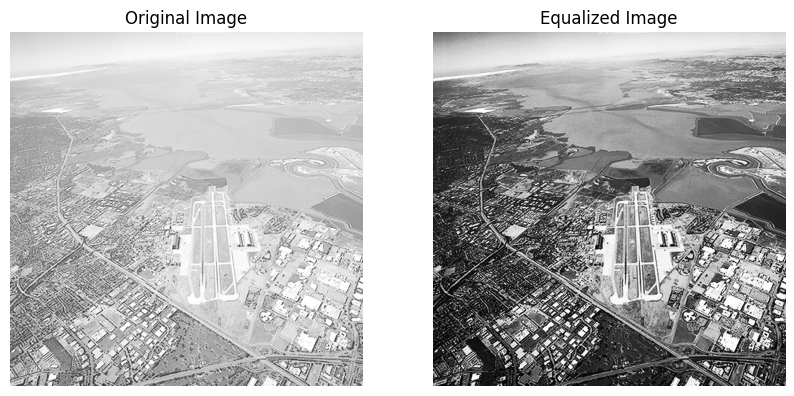

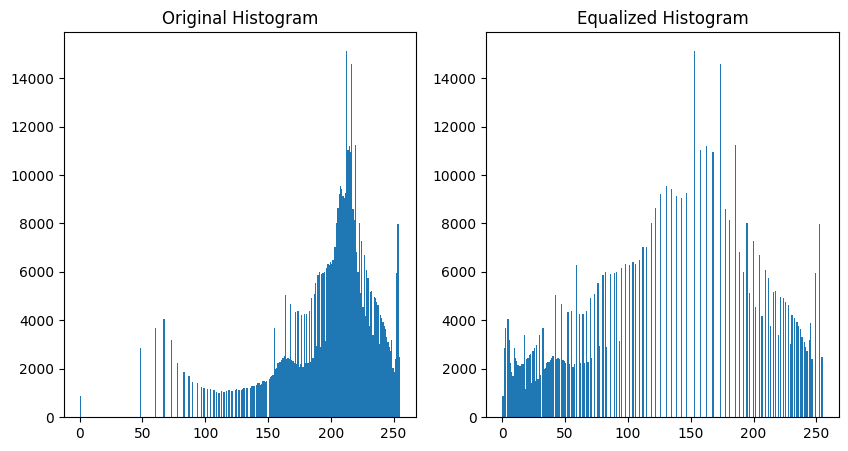

In [4]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


def histogram_equalization(image):
    #Flatten image to 1D
    flat = image.flatten()

    #Histogram
    hist, bins = np.histogram(flat, bins=256, range=[0,256])

    #CDF
    cdf = hist.cumsum()

    #Normalize CDF
    cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
    cdf_normalized = cdf_normalized.astype(np.uint8)

    #Map values
    equalized = cdf_normalized[flat]

    #Reshape back to image
    return equalized.reshape(image.shape)


# Load image (grayscale)
img = cv.imread("/content/input_runway.png", cv.IMREAD_GRAYSCALE)

#Apply histogram equalization
equalized_img = histogram_equalization(img)


# -------- Display --------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(equalized_img, cmap='gray')
plt.title("Equalized Image")
plt.axis("off")

plt.show()

# -------- Save Output --------
cv.imwrite("output_hist_equalized.png", equalized_img)

# -------- Histograms --------
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(img.ravel(), bins=256, range=(0,255))
plt.title("Original Histogram")
plt.savefig("hist_original.png")

plt.subplot(1,2,2)
plt.hist(equalized_img.ravel(), bins=256, range=(0,255))
plt.title("Equalized Histogram")
plt.savefig("hist_equalized.png")

plt.show()
